In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [11]:
df = pd.read_csv("C:/Users/USER/Downloads/job_salary_prediction_dataset.csv")
print(df.head())


            job_title  experience_years education_level  skills_count  \
0         AI Engineer                10        Bachelor             2   
1        Data Analyst                 5        Bachelor            17   
2  Frontend Developer                18             PhD             4   
3    Business Analyst                19             PhD            13   
4     Product Manager                15        Bachelor             7   

        industry company_size   location remote_work  certifications  salary  
0     Healthcare       Medium      India      Hybrid               2  109413  
1        Telecom        Small  Australia          No               0   93764  
2          Media       Medium  Singapore          No               1  148123  
3         Retail       Medium     Canada         Yes               0  189123  
4  Manufacturing        Large     Sweden         Yes               0  165069  


DATA PREPROCESSING

In [12]:
le = LabelEncoder()

categorical_cols = ['job_title','education_level','industry',
                    'company_size','location','remote_work']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

    Define Features & Target 
    Train-Test Split

In [13]:
X = df.drop("salary", axis=1)
y = df["salary"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

MODEL BUILDING
1. Linear Regression 2. Decision Tree
3.Random Forest (BEST MODEL)

In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
#2. Decision Tree
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
#23.Random Forest (BEST MODEL)
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

5. MODEL EVALUATION

In [15]:
# 📌 7. Evaluation Function
def evaluate(y_test, y_pred, model_name):
    print(f"--- {model_name} ---")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2 Score:", r2_score(y_test, y_pred))
    print()


# 📌 8. Evaluate All Models
evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_dt, "Decision Tree")
evaluate(y_test, y_pred_rf, "Random Forest")

--- Linear Regression ---
MAE: 21740.623781383027
MSE: 756119410.2741934
R2 Score: 0.4559758296725779

--- Decision Tree ---
MAE: 7598.5998
MSE: 95556584.26261
R2 Score: 0.9312475109534123

--- Random Forest ---
MAE: 5183.920597850952
MSE: 42996929.96848074
R2 Score: 0.96906392186884



VISUALIZATION

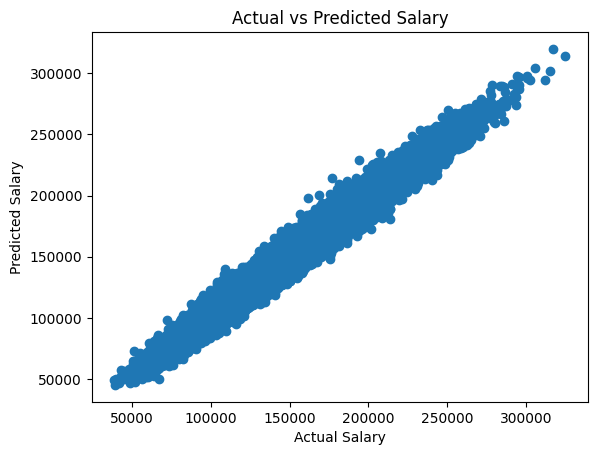

In [16]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()